# 06 · EDA de perfilado de zonas para clustering (Issue #25)

**Responsable:** Integrante 3 (Clustering + Dashboard) · **Fase CRISP-ML:** 3 · **Alimenta a:** #26 (features + línea base z-score), #27 (K-Means formal).

Análisis exploratorio sobre el **dataset analítico unificado** (`data/03_primary/dataset_analitico.parquet`),
para caracterizar cómo se compone el delito en cada localidad (no solo cuánto, sino **de qué tipo**) y
adelantar una hipótesis visual de en cuántos perfiles distintos podrían agruparse las 20 localidades.

> **Alcance:** este notebook es EDA, no modelado. El K-Means formal (features estandarizadas con NUSE/IPM,
> elbow + silhouette cuantitativos, `k` final justificado) es la Issue #27; aquí solo se explora visualmente.

**Secciones**
1. Perfiles delictivos por localidad (proporción de cada tipo de delito)
2. Tendencia por año por localidad-tipo (¿sube o baja?)
3. Hipótesis preliminar de cuántos perfiles existen (dendrograma)


In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, zscore
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Paleta del proyecto (consistente con 01_EDA_exploracion_datos.ipynb, el dashboard y la app movil)
COLORES = {
    "bajo":   "#17D05B",
    "medio":  "#F5A623",
    "alto":   "#E05252",
    "neutro": "#C89B3C",
    "fondo":  "#0D1117",
}

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.axisbelow": True})
sns.set_style("whitegrid")

DF = pd.read_parquet("../data/03_primary/dataset_analitico.parquet")
DF["localidad_nombre"] = DF["localidad_nombre"].astype("string").astype(object)
DF["tipo_delito_nombre"] = DF["tipo_delito_nombre"].astype("string").astype(object)
print("Dataset:", DF.shape, "| columnas:", list(DF.columns))
print("Localidades:", DF["localidad_nombre"].nunique(), "| tipos de delito:", DF["tipo_delito_nombre"].nunique(),
      "| anios:", sorted(DF["anio"].unique()))
assert DF.shape == (1760, 11), "forma inesperada del dataset analitico"
assert DF["localidad_nombre"].nunique() == 20 and DF["tipo_delito_nombre"].nunique() == 11
DF.head()


Dataset: (1760, 11) | columnas: ['cod_localidad', 'localidad_nombre', 'anio', 'tipo_delito', 'tipo_delito_nombre', 'conteo_siedco', 'conteo_nuse', 'poblacion', 'ipm_nbi', 'split', 'riesgo_alto']
Localidades: 20 | tipos de delito: 11 | anios: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,cod_localidad,localidad_nombre,anio,tipo_delito,tipo_delito_nombre,conteo_siedco,conteo_nuse,poblacion,ipm_nbi,split,riesgo_alto
0,01,USAQUEN,2018,DS,Delitos Sexuales,263,223460,534118,2.424007,train,0
1,01,USAQUEN,2018,H,Homicidios,36,223460,534118,2.424007,train,0
2,01,USAQUEN,2018,HA,Hurto Automotores,158,223460,534118,2.424007,train,0
3,01,USAQUEN,2018,HB,Hurto Bicicletas,789,223460,534118,2.424007,train,1
4,01,USAQUEN,2018,HC,Hurto Comercio,1295,223460,534118,2.424007,train,1


## Sección 1 — Perfiles delictivos por localidad

¿De qué está hecho el delito en cada localidad? No el volumen (eso ya lo cubre
`01_EDA_exploracion_datos.ipynb`), sino la **composición**: qué proporción de los delitos
registrados en 2018–2025 corresponde a cada tipo. Dos localidades pueden tener volúmenes muy
distintos y aun así compartir perfil (o al revés) — esa composición es lo que el clustering de
#27 necesita capturar.


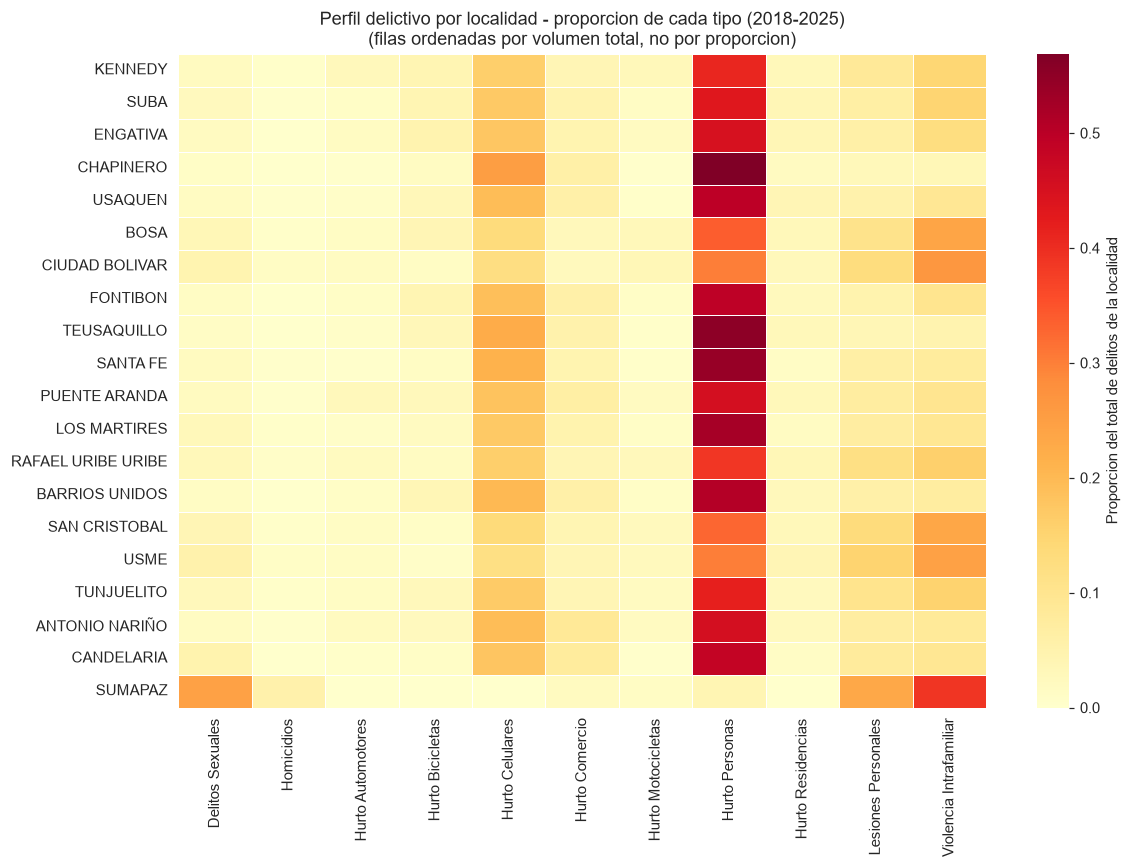

Tipo de delito dominante (mayor proporcion) por localidad:
Hurto Personas             19
Violencia Intrafamiliar     1

Composicion completa - Sumapaz vs. dos localidades del sur (referencia):
localidad_nombre         SUMAPAZ  RAFAEL URIBE URIBE  SAN CRISTOBAL
tipo_delito_nombre                                                 
Delitos Sexuales           0.247               0.031          0.040
Homicidios                 0.055               0.007          0.006
Hurto Automotores          0.000               0.021          0.015
Hurto Bicicletas           0.000               0.017          0.011
Hurto Celulares            0.000               0.161          0.136
Hurto Comercio             0.021               0.038          0.041
Hurto Motocicletas         0.014               0.028          0.026
Hurto Personas             0.041               0.387          0.327
Hurto Residencias          0.000               0.034          0.031
Lesiones Personales        0.233               0.118       

In [2]:
piv_siedco = DF.pivot_table(index="localidad_nombre", columns="tipo_delito_nombre", values="conteo_siedco", aggfunc="sum")
PROP = piv_siedco.div(piv_siedco.sum(axis=1), axis=0)
assert np.allclose(PROP.sum(axis=1), 1.0), "las proporciones por localidad deben sumar 1"

orden_volumen = piv_siedco.sum(axis=1).sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(PROP.loc[orden_volumen], cmap="YlOrRd", linewidths=.4, linecolor="white", cbar_kws={"label": "Proporcion del total de delitos de la localidad"}, ax=ax)
titulo = "Perfil delictivo por localidad - proporcion de cada tipo (2018-2025)"
titulo += "\n(filas ordenadas por volumen total, no por proporcion)"
ax.set_title(titulo)
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

top_perfil = PROP.idxmax(axis=1)
print("Tipo de delito dominante (mayor proporcion) por localidad:")
print(top_perfil.value_counts().to_string())
print()
print("Composicion completa - Sumapaz vs. dos localidades del sur (referencia):")
print(PROP.loc[["SUMAPAZ", "RAFAEL URIBE URIBE", "SAN CRISTOBAL"]].round(3).T.to_string())

**Interpretación.** El **tipo dominante por sí solo casi no diferencia localidades**: Hurto a
Personas es el tipo con mayor proporción en **19 de las 20 localidades** (entre 30% y 57% del total
según la zona), reflejo de que ya en `01_EDA_exploracion_datos.ipynb` se identificó como el delito
más frecuente en toda la ciudad. La única excepción es **Sumapaz**, donde el tipo dominante es
**Violencia Intrafamiliar (39%)** — un perfil cualitativamente distinto al resto, consistente con ser
la única localidad rural y de muy baja población. Esto confirma que **el perfil de zona no se puede
leer del top-1**: hace falta la composición completa. Al comparar Sumapaz con dos localidades del sur
(Rafael Uribe Uribe, San Cristóbal) se ve el patrón que ya señalaba `docs/HANDOFF_INT1.md` — la
proporción combinada de Violencia Intrafamiliar y Lesiones Personales es **62% en Sumapaz** y **28%–37%
en Rafael Uribe Uribe y San Cristóbal**, frente a apenas **6%–8% en localidades comerciales como
Chapinero o Teusaquillo**, donde el Hurto a Personas domina con más fuerza. Esa asimetría composicional
es la señal que un clustering sobre proporciones (no sobre volúmenes crudos) debería capturar.

## Sección 2 — Tendencia por año por localidad-tipo

¿Cada combinación localidad–tipo de delito sube, baja o se mantiene estable entre 2018 y 2025? Se
ajusta una regresión lineal simple (`conteo_siedco` contra `anio`) por cada una de las 20 × 11 = 220
combinaciones y se clasifica la pendiente relativa al nivel medio de esa serie. **Nota:** 2020 tiene una
caída marcada por el confinamiento (ver `01_EDA_exploracion_datos.ipynb`, Sección 2); una tendencia de
varios años no debe leerse como si ese año fuera el patrón normal.


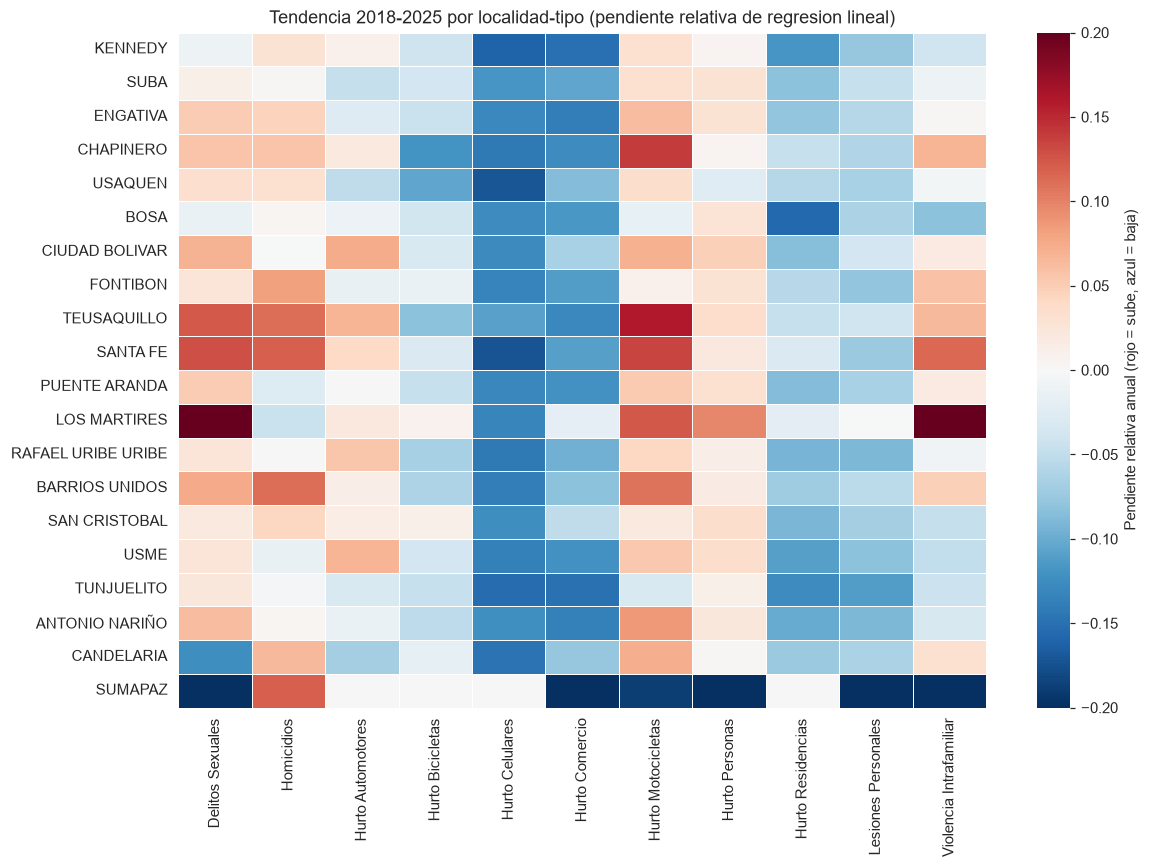

Conteo de combinaciones localidad-tipo por tendencia:
tendencia
baja       106
estable     61
sube        53

Tendencia agregada por tipo de delito (cuantas localidades suben/bajan/estable):
tendencia                baja  estable  sube
tipo_delito_nombre                          
Delitos Sexuales            2        8    10
Homicidios                  1        9    10
Hurto Automotores           4       11     5
Hurto Bicicletas           15        5     0
Hurto Celulares            19        1     0
Hurto Comercio             19        1     0
Hurto Motocicletas          2        3    15
Hurto Personas              1       13     6
Hurto Residencias          17        3     0
Lesiones Personales        19        1     0
Violencia Intrafamiliar     7        6     7


In [3]:
filas = []
for (loc, tipo), g in DF.groupby(["localidad_nombre", "tipo_delito_nombre"]):
    g = g.sort_values("anio")
    pendiente, _, _, _, _ = linregress(g["anio"], g["conteo_siedco"])
    media = g["conteo_siedco"].mean()
    pendiente_rel = (pendiente / media) if media > 0 else 0.0
    filas.append({"localidad_nombre": loc, "tipo_delito_nombre": tipo, "pendiente_rel": pendiente_rel})
TENDENCIA = pd.DataFrame(filas)

UMBRAL_TENDENCIA = 0.03  # pendiente relativa: > +3%/anio promedio = sube, < -3%/anio = baja
TENDENCIA["tendencia"] = np.select(
    [TENDENCIA["pendiente_rel"] > UMBRAL_TENDENCIA, TENDENCIA["pendiente_rel"] < -UMBRAL_TENDENCIA],
    ["sube", "baja"], default="estable",
)
assert len(TENDENCIA) == 220, "se esperan 20 localidades x 11 tipos = 220 combinaciones"

piv_tendencia = TENDENCIA.pivot(index="localidad_nombre", columns="tipo_delito_nombre", values="pendiente_rel")
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(piv_tendencia.loc[orden_volumen], cmap="RdBu_r", center=0, vmin=-0.2, vmax=0.2,
            linewidths=.4, linecolor="white",
            cbar_kws={"label": "Pendiente relativa anual (rojo = sube, azul = baja)"}, ax=ax)
ax.set_title("Tendencia 2018-2025 por localidad-tipo (pendiente relativa de regresion lineal)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

print("Conteo de combinaciones localidad-tipo por tendencia:")
print(TENDENCIA["tendencia"].value_counts().to_string())
print()
print("Tendencia agregada por tipo de delito (cuantas localidades suben/bajan/estable):")
print(TENDENCIA.groupby(["tipo_delito_nombre", "tendencia"]).size().unstack(fill_value=0).to_string())


**Interpretación.** La tendencia **no es uniforme por tipo de delito** — hay patrones consistentes
en casi todas las localidades:

- **Sube en casi toda la ciudad:** Hurto de Motocicletas (15 de 20 localidades en tendencia "sube"),
  Delitos Sexuales y Homicidios (10 de 20 cada uno, con solo 1–2 localidades en baja).
- **Baja en casi toda la ciudad:** Lesiones Personales, Hurto de Celulares y Hurto de Comercio (19 de 20
  localidades cada uno), y Hurto de Residencias y Hurto de Bicicletas (17 y 15 de 20).
- **Sumapaz es la serie más ruidosa** (pendientes relativas de hasta −53%): con conteos anuales muy
  bajos (decenas de casos), una variación pequeña en términos absolutos se traduce en una pendiente
  relativa enorme — hay que leer sus tendencias con cautela, no como una señal fuerte.

Que el Hurto de Motocicletas suba de forma generalizada mientras el Hurto de Celulares y de Comercio bajan
de forma igual de generalizada sugiere que estos patrones responden a una dinámica **de tipo de delito a
nivel ciudad** más que a algo específico de cada localidad — una hipótesis a tener en cuenta si #26/#27
deciden incluir la tendencia como feature adicional al perfil estático de proporciones.


## Sección 3 — Hipótesis preliminar de cuántos perfiles existen

Sobre la matriz de proporciones de la Sección 1 (estandarizada por tipo de delito, para que ningún tipo
de alto volumen domine la distancia), se corre un clustering jerárquico (`ward`) solo para **leer
visualmente** en cuántos grupos parecen separarse las 20 localidades. **Esto no es el clustering final**:
no hay estandarización con las features completas (NUSE, IPM), ni elección formal de `k` por
elbow/silhouette, ni asignación de cluster por localidad — todo eso es la Issue #27.


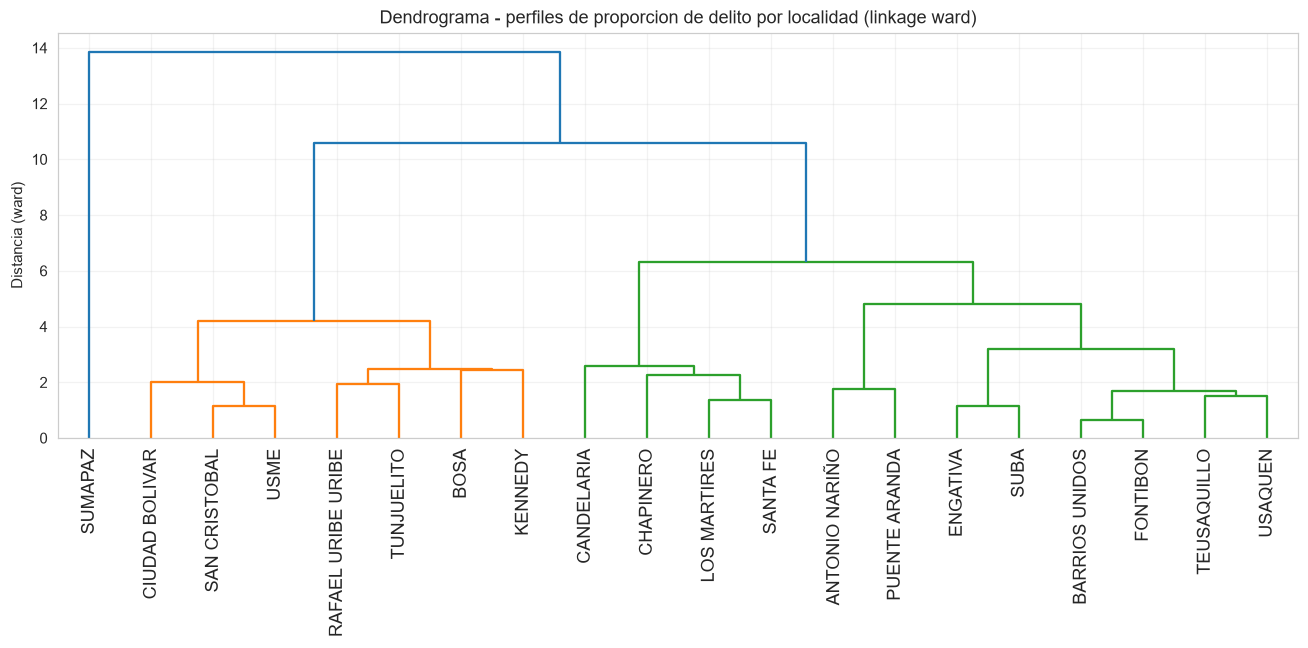

Tamano de los grupos para distintos cortes de k:
  k=2: tamanos = [19, 1]
  k=3: tamanos = [12, 7, 1]
  k=4: tamanos = [8, 7, 4, 1]
  k=5: tamanos = [7, 6, 4, 2, 1]
  k=6: tamanos = [6, 4, 4, 3, 2, 1]


In [4]:
PROP_Z = PROP.apply(zscore)
Z = linkage(PROP_Z.values, method="ward")

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(Z, labels=PROP_Z.index.tolist(), leaf_rotation=90,
           color_threshold=0.7 * max(Z[:, 2]), ax=ax)
ax.set_title("Dendrograma - perfiles de proporcion de delito por localidad (linkage ward)")
ax.set_ylabel("Distancia (ward)")
plt.tight_layout(); plt.show()

print("Tamano de los grupos para distintos cortes de k:")
for k in (2, 3, 4, 5, 6):
    grupos = fcluster(Z, t=k, criterion="maxclust")
    tamanos = sorted((int(x) for x in np.bincount(grupos)[1:]), reverse=True)
    print(f"  k={k}: tamanos = {tamanos}")


**Interpretación.** Sumapaz aparece como grupo propio de tamaño 1 en **todos** los cortes de `k`
probados (2 a 6): su perfil es tan distinto que el algoritmo lo aísla de inmediato, confirmando la
lectura de la Sección 1. Descontando Sumapaz, el resto de la ciudad se reparte así: con `k=2` casi toda
la ciudad queda en un único grupo de 19 localidades (no aporta información útil); con `k=3` se abren
dos grupos de 12 y 7; con `k=4`, de 8, 7 y 4; a partir de `k=5` empiezan a aparecer grupos de tamaño 2,
señal de que se está fragmentando de más.

**Hipótesis preliminar:** probablemente existan **entre 3 y 4 perfiles principales** entre las 19
localidades restantes, más Sumapaz como caso atípico a tratar aparte (incluir, excluir o cluster propio
— decisión pendiente, ver `docs/HANDOFF_INT1.md`). Con `k=3`, un grupo de 12 localidades
comerciales/alta afluencia (incluye Chapinero, Teusaquillo y Candelaria) y un grupo de 7 localidades del
sur con mayor peso relativo de violencia interpersonal (Rafael Uribe, San Cristóbal, Usme, junto con
Bosa, Ciudad Bolívar, Kennedy y Tunjuelito) quedan claramente separados — en la línea de lo ya
documentado en `docs/HANDOFF_INT1.md`. Con `k=4` el grupo del sur se mantiene intacto, pero el grupo
comercial se divide en dos: Chapinero y Candelaria quedan con Los Mártires y Santa Fe (4 localidades),
mientras Teusaquillo pasa a un grupo más heterogéneo de 8 localidades (junto con Antonio Nariño, Barrios
Unidos, Engativá, Fontibón, Puente Aranda, Suba y Usaquén) — señal de que el perfil "comercial" es menos
homogéneo de lo que parece a primera vista. La Issue #27 debe confirmar el número de perfiles y su
composición exacta con el método formal (elbow + silhouette sobre las features completas).